<a href="https://colab.research.google.com/github/AdityaChoudhary-max/CODSOFT/blob/main/CREDIT_CARD_FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [112]:
train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")

In [113]:
train = train.sample(n=200000, random_state=42)

In [114]:
print("Training Dataset Shape :", train.shape)
print("Testing Dataset Shape :", test.shape)

Training Dataset Shape : (200000, 23)
Testing Dataset Shape : (555719, 23)


In [115]:
print(train.head())

         Unnamed: 0 trans_date_trans_time            cc_num  \
1045211     1045211   2020-03-09 15:09:26      577588686219   
547406       547406   2019-08-22 15:49:01    30376238035123   
110142       110142   2019-03-04 01:34:16  4658490815480264   
1285953     1285953   2020-06-16 20:04:38  3514897282719543   
271705       271705   2019-05-14 05:54:48  6011381817520024   

                                            merchant        category     amt  \
1045211                              fraud_Towne LLC        misc_pos  194.51   
547406                             fraud_Friesen Ltd  health_fitness   52.32   
110142                                fraud_Mohr Inc    shopping_pos    6.53   
1285953                      fraud_Gaylord-Powlowski            home    7.33   
271705   fraud_Christiansen, Goyette and Schamberger   gas_transport   64.29   

           first        last gender                        street  ...  \
1045211    James  Strickland      M            25454 Leonard Lake 

In [116]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1045211 to 140417
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             200000 non-null  int64  
 1   trans_date_trans_time  200000 non-null  object 
 2   cc_num                 200000 non-null  int64  
 3   merchant               200000 non-null  object 
 4   category               200000 non-null  object 
 5   amt                    200000 non-null  float64
 6   first                  200000 non-null  object 
 7   last                   200000 non-null  object 
 8   gender                 200000 non-null  object 
 9   street                 200000 non-null  object 
 10  city                   200000 non-null  object 
 11  state                  200000 non-null  object 
 12  zip                    200000 non-null  int64  
 13  lat                    200000 non-null  float64
 14  long                   200000 non-n

In [117]:
print(train.describe())

         Unnamed: 0        cc_num            amt            zip           lat  \
count  2.000000e+05  2.000000e+05  200000.000000  200000.000000  200000.00000   
mean   6.494417e+05  4.153482e+17      70.268739   48810.448745      38.54406   
std    3.738884e+05  1.306288e+18     160.923758   26918.935409       5.07508   
min    5.000000e+00  6.041621e+10       1.000000    1257.000000      20.02710   
25%    3.261095e+05  1.800429e+14       9.640000   26237.000000      34.66890   
50%    6.492790e+05  3.519607e+15      47.510000   48174.000000      39.35430   
75%    9.730945e+05  4.642255e+15      83.050000   72042.000000      41.94040   
max    1.296673e+06  4.992346e+18   28948.900000   99783.000000      66.69330   

                long      city_pop     unix_time      merch_lat  \
count  200000.000000  2.000000e+05  2.000000e+05  200000.000000   
mean      -90.247794  8.834341e+04  1.349282e+09      38.545386   
std        13.780400  3.030653e+05  1.282529e+07       5.108959   
mi

In [118]:
print(train.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [119]:
print(train["is_fraud"].value_counts())

is_fraud
0    198811
1      1189
Name: count, dtype: int64


In [120]:
print(train["is_fraud"].value_counts(normalize=True) * 100)

is_fraud
0    99.4055
1     0.5945
Name: proportion, dtype: float64


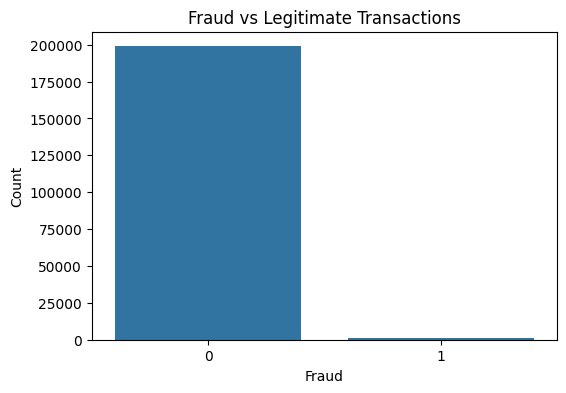

In [121]:
plt.figure(figsize=(6,4))

sns.countplot(x="is_fraud", data=train)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Fraud")
plt.ylabel("Count")

plt.show()

In [122]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'city',
    'state',
    'dob',
    'trans_num'
]

train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [123]:
categorical_cols = train.select_dtypes(include='object').columns

for col in categorical_cols:

    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]])
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

In [124]:
ad_train = train.drop("is_fraud", axis=1)
ch_train = train["is_fraud"]

In [125]:
ad_test = test.drop("is_fraud", axis=1)
ch_test = test["is_fraud"]

In [126]:
print(ad_train.shape)
print(ch_test.shape)

(200000, 12)
(555719,)


Decision Tree

In [127]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(ad_train, ch_train)

dt_pred = dt.predict(ad_test)

In [128]:
print("Accuracy :",
      accuracy_score(ch_test, dt_pred)*100)

Accuracy : 99.19023823191218


In [129]:
print(classification_report(ch_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.25      0.56      0.35      2145

    accuracy                           0.99    555719
   macro avg       0.62      0.77      0.67    555719
weighted avg       1.00      0.99      0.99    555719



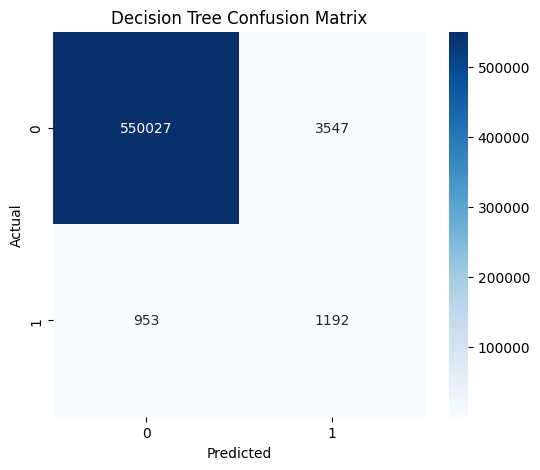

In [130]:
cm = confusion_matrix(ch_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

logistic Regression

In [131]:
lr = LogisticRegression(
    solver="liblinear",
    max_iter=500
)

lr.fit(ad_train, ch_train)

lr_pred = lr.predict(ad_test)

In [132]:
print("Accuracy :",
      accuracy_score(ch_test, lr_pred)*100)

Accuracy : 99.61401355721146


In [133]:
print(classification_report(ch_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


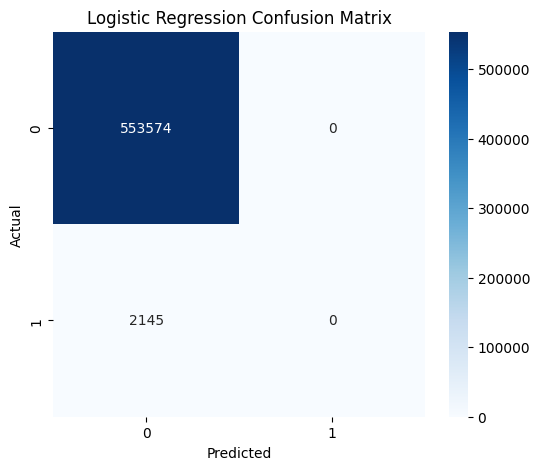

In [134]:
cm = confusion_matrix(ch_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest

In [135]:
rf = RandomForestClassifier(
    n_estimators=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(ad_train, ch_train)
rf_pred = rf.predict(ad_test)

In [136]:
print("Accuracy :",
      accuracy_score(ch_test, rf_pred)*100)

Accuracy : 99.65648106327119


In [137]:
print(classification_report(ch_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.90      0.12      0.22      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.56      0.61    555719
weighted avg       1.00      1.00      1.00    555719



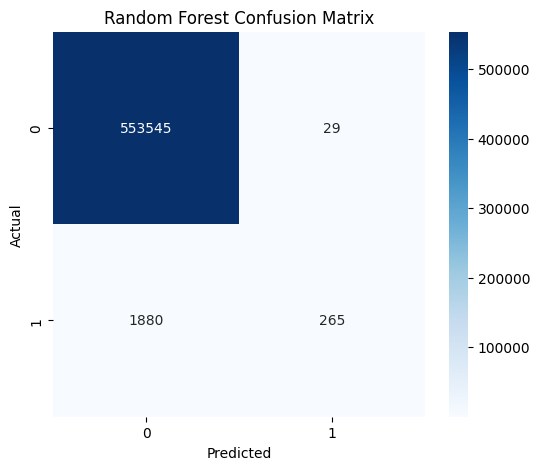

In [138]:
cm = confusion_matrix(ch_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

comparison

In [139]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(ch_test, lr_pred)*100,
        accuracy_score(ch_test, dt_pred)*100,
        accuracy_score(ch_test, rf_pred)*100
    ]
})

print(results)

                 Model   Accuracy
0  Logistic Regression  99.614014
1        Decision Tree  99.190238
2        Random Forest  99.656481


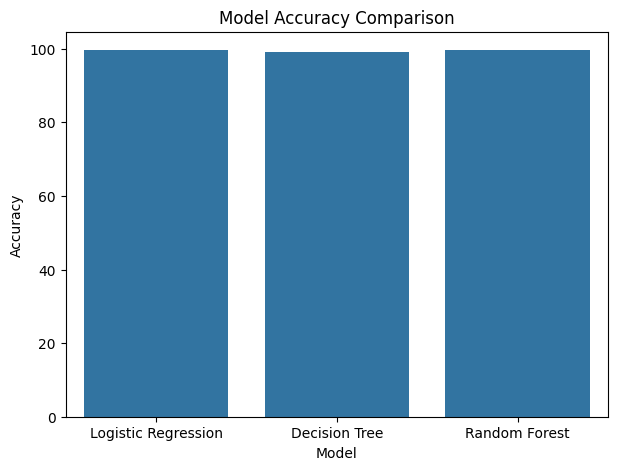

In [140]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [141]:
importance = pd.DataFrame({
    "Feature": ad_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

       Feature  Importance
2          amt    0.662989
1     category    0.106509
9    unix_time    0.035443
0     merchant    0.027664
10   merch_lat    0.026103
7     city_pop    0.025401
8          job    0.023761
11  merch_long    0.023155
4          zip    0.022138
5          lat    0.021897


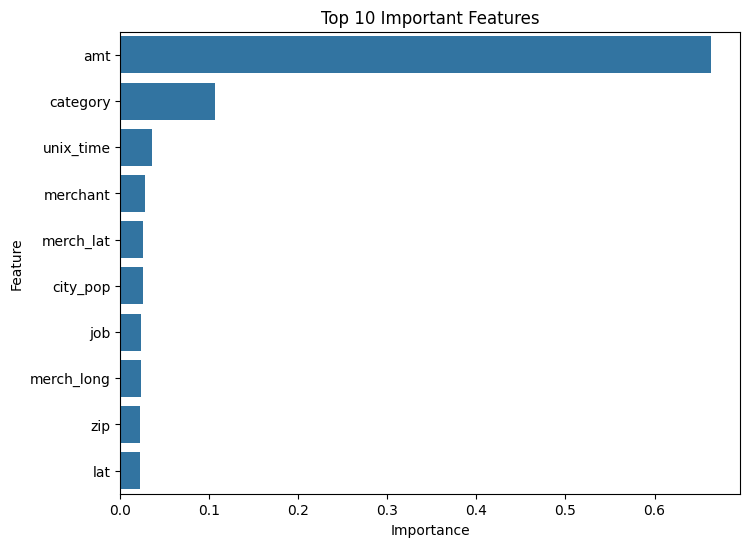

In [142]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

In [143]:
sample = ad_test.iloc[[1000]]

actual = ch_test.iloc[1000]

prediction = rf.predict(sample)

print("Actual Status :",
      "Fraud" if actual == 1 else "Legitimate")

print("Predicted Status :",
      "Fraud" if prediction[0] == 1 else "Legitimate")

if actual == prediction[0]:
    print("Correct Prediction")
else:
    print("Incorrect Prediction")

Actual Status : Legitimate
Predicted Status : Legitimate
Correct Prediction


In [144]:
print(results)

best_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

print("\nBest Performing Model :", best_model)

                 Model   Accuracy
0  Logistic Regression  99.614014
1        Decision Tree  99.190238
2        Random Forest  99.656481

Best Performing Model : Random Forest
